<a href="https://colab.research.google.com/github/aiyman14/DACSS-758/blob/main/Week8LabPython.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 62.5 MB/s eta 0:00:00


In [2]:
# for preprocessing
from gensim.parsing.preprocessing import preprocess_string, strip_tags, strip_punctuation, strip_short
from gensim.parsing.preprocessing import strip_multiple_whitespaces, strip_numeric, remove_stopwords

In [3]:
import pandas as pd

In [4]:
# read in txt file (uploaded directly to Colab)
text_file = open("/content/prideprejudice (1).txt", "r", encoding="utf-8")
prideprej = text_file.readlines()
text_file.close()

In [5]:
# preprocess all at once!
prideprej_lower = [item.lower() for item in prideprej]
CUSTOM_FILTERS = [strip_punctuation, strip_multiple_whitespaces, remove_stopwords, strip_short]
prideprej_toks = [preprocess_string(item, CUSTOM_FILTERS) for item in prideprej_lower]

In [6]:
prideprej_toks[0:10]

[['pride', 'prejudice'],
 [],
 ['jane', 'austen'],
 [],
 [],
 [],
 ['chapter'],
 [],
 [],
 ['truth', 'universally', 'acknowledged', 'single', 'man', 'possession']]

In [7]:
prideprej_toks_merged = [' '.join(item) for item in prideprej_toks]

In [8]:
prideprej_toks_merged[0:10]

['pride prejudice',
 '',
 'jane austen',
 '',
 '',
 '',
 'chapter',
 '',
 '',
 'truth universally acknowledged single man possession']

# AFINN

In [9]:
!pip install afinn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.6/52.6 kB 2.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for afinn: filename=afinn-0.1-py3-none-any.whl size=53431 sha256=9a818836a77e593b841531bffdae9a5782f59d978cf702f5cb114d6559b3e8f6
  Stored in directory: /root/.cache/pip/wheels/f9/72/27/74994e77200dae3d6aea2b546264500cee21f738c51241320b
Successfully built afinn


In [10]:
from afinn import Afinn

In [11]:
# Instantiate the Afinn object
# 'emoticons=True' can be passed as an argument to include emoticon scoring
afn = Afinn(emoticons=False)

# Compute scores for each quasi-sentence
scores = [afn.score(qs) for qs in prideprej_toks_merged]

# Determine the sentiment label
sentiment_labels = ['positive' if score > 0 else 'negative' if score < 0 else 'neutral' for score in scores]

# Store results in dataframe
results = {
    'OG Text': prideprej,
    'Cleaned Text': prideprej_toks_merged,
    'Score': scores,
    'Sentiment Label': sentiment_labels
}
results_df = pd.DataFrame(results)
results_df.head()

,OG Text,Cleaned Text,Score,Sentiment Label
0,PRIDE AND PREJUDICE\n,pride prejudice,0.0,neutral
1,\n,,0.0,neutral
2,By Jane Austen\n,jane austen,0.0,neutral
3,\n,,0.0,neutral
4,\n,,0.0,neutral


In [12]:
# find most positive texts
results_df[results_df["Sentiment Label"]=="positive"].sort_values(by='Score', ascending=False)

,OG Text,Cleaned Text,Score,Sentiment Label
12698,pleased--so happy. Such a charming man!--so ha...,pleased happy charming man handsome tall,12.0,positive
12694,"""Good gracious! Lord bless me! only think! dea...",good gracious lord bless think dear darcy,10.0,positive
4415,"rapturous expressions, of his happiness in hav...",rapturous expressions happiness having obtaine...,10.0,positive
6298,every hope of happiness for the most affection...,hope happiness affectionate generous heart,10.0,positive
241,"delighted with him. He was quite young, wonder...",delighted young wonderfully handsome extremely,10.0,positive
...,...,...,...,...
10039,silent till they reached the house. Their fath...,silent till reached house father went,1.0,positive
10035,"""Ten thousand pounds! Heaven forbid! How is ha...",thousand pounds heaven forbid half sum,1.0,positive
10016,are two things that I want very much to know; ...,things want know money,1.0,positive
29,"""_You_ want to tell me, and I have no objectio...",want tell objection hearing,1.0,positive


In [13]:
# find most negative texts
results_df[results_df["Sentiment Label"]=="negative"].sort_values(by='Score', ascending=True)

,OG Text,Cleaned Text,Score,Sentiment Label
12373,"""Hate you! I was angry perhaps at first, but m...",hate angry anger soon began,-9.0,negative
9097,"""I am grieved indeed,"" cried Darcy; ""grieved--...",grieved cried darcy grieved shocked,-8.0,negative
11125,was hurt and distressed to a most painful degr...,hurt distressed painful degree distinction ill,-8.0,negative
1047,"""Oh! I am not afraid of her dying. People do n...",afraid dying people die little trifling,-8.0,negative
844,"""You excel so much in the dance, Miss Eliza, t...",excel dance miss eliza cruel deny,-7.0,negative
...,...,...,...,...
3638,not use the short pause he allowed in any atte...,use short pause allowed attempt stop,-1.0,negative
66,I do not pretend to be anything extraordinary ...,pretend extraordinary woman,-1.0,negative
92,all silly and ignorant like other girls; but L...,silly ignorant like girls lizzy,-1.0,negative
27,"""Do you not want to know who has taken it?"" cr...",want know taken cried wife impatiently,-1.0,negative


In [14]:
results_df.iloc[9097]['OG Text']

'"I am grieved indeed," cried Darcy; "grieved--shocked. But is it\n'

# VADER Dictionary

Useful tutorial: https://blog.jetbrains.com/pycharm/2024/12/introduction-to-sentiment-analysis-in-python/

In [15]:
from nltk.sentiment.vader import SentimentIntensityAnalyzer
import nltk

In [16]:
nltk.download('vader_lexicon')

[nltk_data] Downloading package vader_lexicon to /root/nltk_data...


True

In [17]:
import re
import matplotlib.pyplot as plt
import numpy as np

In [18]:
# instantiate
analyzer = SentimentIntensityAnalyzer()
# test
analyzer.polarity_scores("hello there my dear friend")

{'neg': 0.0, 'neu': 0.341, 'pos': 0.659, 'compound': 0.7003}

In [19]:
# calculate scores
positive = [analyzer.polarity_scores(qs)['pos'] for qs in prideprej_toks_merged]
negative = [analyzer.polarity_scores(qs)['neg'] for qs in prideprej_toks_merged]

# Store results in dataframe
results = {
    'OG Text': prideprej,
    'Cleaned Text': prideprej_toks_merged,
    'Positive': positive,
    'Negative': negative
}
results_df = pd.DataFrame(results)
results_df.head()

,OG Text,Cleaned Text,Positive,Negative
0,PRIDE AND PREJUDICE\n,pride prejudice,0.421,0.579
1,\n,,0.000,0.000
2,By Jane Austen\n,jane austen,0.000,0.000
3,\n,,0.000,0.000
4,\n,,0.000,0.000


In [20]:
# find most positive texts
results_df.sort_values(by='Positive', ascending=False)

,OG Text,Cleaned Text,Positive,Negative
3258,"opportunity.""\n",opportunity,1.0,0.0
3237,"""I hope not.""\n",hope,1.0,0.0
3231,"created_.""\n",created,1.0,0.0
10858,"""And do you like her?""\n",like,1.0,0.0
10835,"""Yes, she did.""\n",yes,1.0,0.0
...,...,...,...,...
1756,\n,,0.0,0.0
1757,"Mrs. Hurst sang with her sister, and while the...",mrs hurst sang sister employed,0.0,0.0
1759,"that lay on the instrument, how frequently Mr....",lay instrument frequently darcy eyes fixed,0.0,0.0
1760,on her. She hardly knew how to suppose that sh...,hardly knew suppose object,0.0,0.0


In [21]:
# find most negative texts
results_df.sort_values(by='Negative', ascending=False)

,OG Text,Cleaned Text,Positive,Negative
12628,"indifference?""\n",indifference,0.0,1.0
12586,"inconvenience.""\n",inconvenience,0.0,1.0
5575,"must have been neglected.""\n",neglected,0.0,1.0
5348,"agitation, cried out--\n",agitation cried,0.0,1.0
5310,forgotten.\n,forgotten,0.0,1.0
...,...,...,...,...
5331,woman whom one cannot regard with too much def...,woman regard deference,0.0,0.0
5332,\n,,0.0,0.0
5333,The evening was spent chiefly in talking over ...,evening spent chiefly talking hertfordshire news,0.0,0.0
5302,"frost, turned back; and while Sir William acco...",frost turned sir william accompanied charlotte,0.0,0.0


In [22]:
# changing unit of analysis
# chapters instead of quasi-sentences
prideprej_split = [re.split('(?<=Chapter)', qs) for qs in prideprej]
prideprej_split = [item for sublist in prideprej_split for item in sublist]
chapter = ""
prideprej_chaps = []
for qs in prideprej_split:
  if "Chapter" in qs:
    # beginning of the chapter
    prideprej_chaps.append(chapter)
    chapter = ""
    chapter = chapter + qs
  elif "Chapter" not in qs:
    # not the beginning of the chapter
    chapter = chapter + qs

print(len(prideprej))
print(len(prideprej_chaps))

13030
61


In [23]:
# redo preprocessing
prideprej_lower = [item.lower() for item in prideprej_chaps]
CUSTOM_FILTERS = [strip_punctuation, strip_multiple_whitespaces, remove_stopwords, strip_short]
prideprej_toks = [preprocess_string(item, CUSTOM_FILTERS) for item in prideprej_lower]

In [24]:
prideprej_toks_merged = [' '.join(item) for item in prideprej_toks]

In [25]:
# calculate scores
positive = [analyzer.polarity_scores(qs)['pos'] for qs in prideprej_toks_merged]
negative = [analyzer.polarity_scores(qs)['neg'] for qs in prideprej_toks_merged]

# Store results in dataframe
results = {
    'OG Text': prideprej_chaps,
    'Cleaned Text': prideprej_toks_merged,
    'Positive': positive,
    'Negative': negative
}
results_df = pd.DataFrame(results)
results_df.head()

,OG Text,Cleaned Text,Positive,Negative
0,PRIDE AND PREJUDICE\n\nBy Jane Austen\n\n\n\n,pride prejudice jane austen,0.312,0.429
1,Chapter 1\n\n\nIt is a truth universally ackno...,chapter truth universally acknowledged single ...,0.360,0.118
2,Chapter 2\n\n\nMr. Bennet was among the earlie...,chapter bennet earliest waited bingley intende...,0.258,0.121
3,"Chapter 3\n\n\nNot all that Mrs. Bennet, howev...",chapter mrs bennet assistance daughters ask su...,0.358,0.105
4,Chapter 4\n\n\nWhen Jane and Elizabeth were al...,chapter jane elizabeth cautious praise bingley...,0.428,0.092


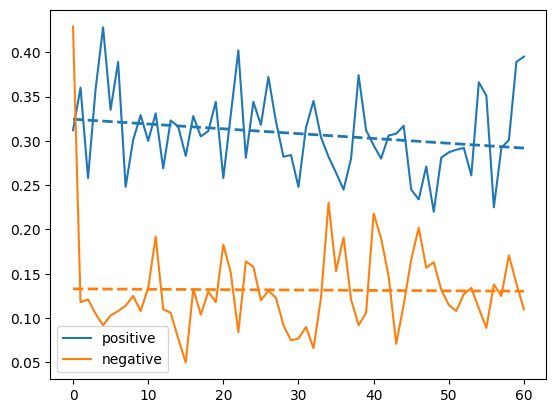

In [26]:
# plot sentiment by chapter

x = range(0,61,1)

plt.plot(results_df['Positive'], label="positive")
m1, b1 = np.polyfit(x, results_df['Positive'], 1)
plt.plot(x, m1*x + b1, color='tab:blue', linestyle='--', linewidth=2)

plt.plot(results_df['Negative'], label="negative")
m2, b2 = np.polyfit(x, results_df['Negative'], 1)
plt.plot(x, m2*x + b2, color='tab:orange', linestyle='--', linewidth=2)

plt.legend()

plt.show()

In [27]:
# unnest list of tokens
prideprej_toks_long = [item for sublist in prideprej_toks for item in sublist]
prideprej_toks_long[0:10]

['pride',
 'prejudice',
 'jane',
 'austen',
 'chapter',
 'truth',
 'universally',
 'acknowledged',
 'single',
 'man']

In [28]:
from collections import Counter

c = Counter(prideprej_toks_long)
word_df = pd.DataFrame(c.items(), columns=['Token', 'Count'])

In [29]:
word_df.head()

,Token,Count
0,pride,47
1,prejudice,6
2,jane,289
3,austen,1
4,chapter,60


In [30]:
word_df['Positive'] = [analyzer.polarity_scores(token)['pos'] for token in word_df['Token']]

In [31]:
word_df.head()

,Token,Count,Positive
0,pride,47,1.0
1,prejudice,6,0.0
2,jane,289,0.0
3,austen,1,0.0
4,chapter,60,0.0


In [32]:
word_df['Positive_Weighted'] = word_df['Positive']*word_df['Count']
word_df.sort_values(by='Positive_Weighted', ascending=False)

,Token,Count,Positive,Positive_Weighted
11,good,200,1.0,200.0
29,dear,156,1.0,156.0
287,great,140,1.0,140.0
164,hope,118,1.0,118.0
259,friend,112,1.0,112.0
...,...,...,...,...
2117,propitious,1,0.0,0.0
2116,tuesday,12,0.0,0.0
2115,remaining,8,0.0,0.0
2113,paying,4,0.0,0.0
